## This dataset shows the Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) that are currently registered through Washington State Department of Licensing (DOL).

Electric Vehicles registered in Washington (2023): https://catalog.data.gov/dataset/electric-vehicle-population-data?from_hint=eyJzb3J0IjoicG9wdWxhcml0eSJ9

Estimated Population of Washington state (Census Data 2023): https://www.census.gov/data/tables/time-series/demo/popest/2020s-counties-total.html

Social Characteristics and Demographics data: https://www.census.gov/programs-surveys/acs/data.html
* Social charateristics: educational attainment, language spoken at home, citizenship status, foreign or non-foreign birth
* Demographics: age, sex, race

Public EV Charging Stations in Washington State (2024): https://geo.wa.gov/

## Limitations:
* For the citizenship status section, this data was taken from the Census (2023). The count for "Not a U.S. Citizen" includes lawful permanent residents (like green card holders), temporary workers, foreign exchange students, refugees, asylees, and undocumented immigrants. Additionally "Foregin-Born Population" counts all non-citizens, including naturalized citizens that were born abroad.
* The Census and Electric Vehicle data was collected in 2023, while the Public EV Charging Stations data was collected in 2024. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re

In [2]:
vehicles_data = pd.read_csv('electric_vehicle.csv')

In [3]:
vehicles_data.head(3)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 GEOID
0,5YJ3E1EA5L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,14.0,102765120,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
1,5YJ3E1EA9K,Thurston,Olympia,WA,98502.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,22.0,326796641,POINT (-122.92018 47.04575),PUGET SOUND ENERGY INC,5.306701e+10
2,5YJSA1H22F,Kitsap,Kingston,WA,98346.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,23.0,166294418,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303509e+10


In [4]:
print(vehicles_data.columns)

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 GEOID'],
      dtype='object')


In [5]:
vehicles_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294193 entries, 0 to 294192
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         294193 non-null  object 
 1   County                                             294183 non-null  object 
 2   City                                               294183 non-null  object 
 3   State                                              294193 non-null  object 
 4   Postal Code                                        294183 non-null  float64
 5   Model Year                                         294193 non-null  int64  
 6   Make                                               294193 non-null  object 
 7   Model                                              294193 non-null  object 
 8   Electric Vehicle Type                              294193 non-null  object

In [6]:
vehicles_data.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 GEOID
count,294183.000000,294193.000000,294180.000000,293431.000000,2.941930e+05,2.941830e+05
mean,98176.263231,2022.312665,36.922578,28.766582,2.504942e+08,5.296843e+10
std,2644.315758,3.085205,76.309809,14.892012,6.244728e+07,1.674636e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.278658e+08,5.303301e+10
50%,98134.000000,2023.000000,0.000000,32.000000,2.675898e+08,5.303303e+10
75%,98390.000000,2024.000000,32.000000,42.000000,2.834127e+08,5.305394e+10
max,99801.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


In [7]:
print("Missing values per column:")
print(vehicles_data.isnull().sum())

Missing values per column:
VIN (1-10)                                             0
County                                                10
City                                                  10
State                                                  0
Postal Code                                           10
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        13
Legislative District                                 762
DOL Vehicle ID                                         0
Vehicle Location                                      18
Electric Utility                                      10
2020 GEOID                                            10
dtype: int64


In [8]:
print(f"\nDuplicate rows found: {vehicles_data.duplicated().sum()}")



Duplicate rows found: 0


In [9]:
vehicles_data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].unique()

array(['Clean Alternative Fuel Vehicle Eligible',
       'Eligibility unknown as battery range has not been researched',
       'Not eligible due to low battery range'], dtype=object)

Renaming Column 'Clean Alternative Fuel Vehicle (CAFV) Eligibility' to 'CAFV Eligibility'

In [10]:
vehicles_data = vehicles_data.rename(columns={'Clean Alternative Fuel Vehicle (CAFV) Eligibility' : 'CAFV Eligibility'})
vehicles_data.head(3)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,CAFV Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 GEOID
0,5YJ3E1EA5L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,14.0,102765120,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
1,5YJ3E1EA9K,Thurston,Olympia,WA,98502.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,22.0,326796641,POINT (-122.92018 47.04575),PUGET SOUND ENERGY INC,5.306701e+10
2,5YJSA1H22F,Kitsap,Kingston,WA,98346.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,23.0,166294418,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303509e+10


In [11]:
vehicles_data['CAFV Eligibility'] = vehicles_data['CAFV Eligibility'].replace({'Clean Alternative Fuel Vehicle Eligible' : 'Eligible', 
                                                                              'Eligibility unknown as battery range has not been researched' : 'Unknown; not enough research', 
                                                                             'Not eligible due to low battery range' : 'Ineligible; low battery range'})
vehicles_data.head(3)


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,CAFV Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 GEOID
0,5YJ3E1EA5L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligible,266.0,14.0,102765120,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
1,5YJ3E1EA9K,Thurston,Olympia,WA,98502.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligible,220.0,22.0,326796641,POINT (-122.92018 47.04575),PUGET SOUND ENERGY INC,5.306701e+10
2,5YJSA1H22F,Kitsap,Kingston,WA,98346.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Eligible,208.0,23.0,166294418,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303509e+10


VIN: Issued by the auto manufacturer using federal and international (ISO 3779) standards.
DOL Vehicle ID: Generated by the state's Department of Licensing (like Washington's DOL) for database management and open-data tracking. 

In [12]:
vehicles_data = vehicles_data.drop(columns=['VIN (1-10)', 'Vehicle Location'])
vehicles_data.head(3)

,County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,CAFV Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Electric Utility,2020 GEOID
0,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligible,266.0,14.0,102765120,PACIFICORP,5.307700e+10
1,Thurston,Olympia,WA,98502.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligible,220.0,22.0,326796641,PUGET SOUND ENERGY INC,5.306701e+10
2,Kitsap,Kingston,WA,98346.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Eligible,208.0,23.0,166294418,PUGET SOUND ENERGY INC,5.303509e+10


In [13]:
pd.set_option('display.float_format', lambda x: '%.1f' % x) # change int display setting
#vehicles_data.head(3).style.format({'2020 GEOID': '{:.0f}'}) # change just for 2020 GEOID
vehicles_data.head(3)

,County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,CAFV Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Electric Utility,2020 GEOID
0,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligible,266.0,14.0,102765120,PACIFICORP,53077001000.0
1,Thurston,Olympia,WA,98502.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligible,220.0,22.0,326796641,PUGET SOUND ENERGY INC,53067011100.0
2,Kitsap,Kingston,WA,98346.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Eligible,208.0,23.0,166294418,PUGET SOUND ENERGY INC,53035090102.0


In [14]:
count_vehicle_county = vehicles_data['County'].value_counts().head(15)
count_vehicle_county

County
King         141971
Snohomish     37128
Pierce        24578
Clark         18365
Thurston      10806
Kitsap        10185
Spokane        8503
Whatcom        7357
Benton         4384
Skagit         3504
Island         3226
Yakima         2166
Chelan         1972
Clallam        1864
Cowlitz        1636
Name: count, dtype: int64

In [15]:
count_vehicle_dist = vehicles_data['Legislative District'].value_counts().head(15)
count_vehicle_dist

Legislative District
41.0    17696
45.0    16349
48.0    15385
1.0     12736
5.0     12401
36.0    10839
46.0    10605
43.0     9398
11.0     9012
44.0     8494
18.0     8232
37.0     8182
34.0     8050
21.0     7693
22.0     7187
Name: count, dtype: int64

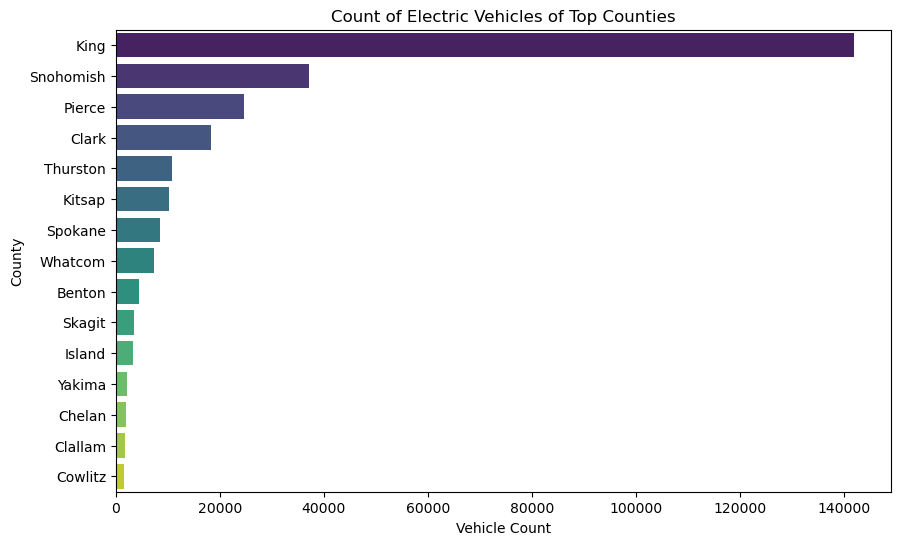

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=count_vehicle_county.values, y=count_vehicle_county.index, hue=count_vehicle_county.index, palette='viridis')

plt.xlabel('Vehicle Count')
plt.title('Count of Electric Vehicles of Top Counties')
plt.show()

https://www.census.gov/programs-surveys/geography/guidance/geo-identifiers.html
understanding geoids

Per Capita 1000 residents per county

In [17]:
ev_counts = vehicles_data['County'].value_counts().reset_index()
ev_counts.columns = ['County', 'EV_Count']
ev_counts

,County,EV_Count
0,King,141971
1,Snohomish,37128
2,Pierce,24578
3,Clark,18365
4,Thurston,10806
...,...,...
252,DeKalb,1
253,Oldham,1
254,Anchorage,1
255,Deschutes,1


In [18]:
census_pop = pd.read_excel('co-est2025-pop-53.xlsx')
census_pop.head(10)

,table with row headers in column A and column headers in rows 3 through 4 (leading dots indicate sub-parts),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,Annual Estimates of the Resident Population fo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Geographic Area,"April 1, 2020 Estimates Base",Population Estimate (as of July 1),NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,2020,2021.0,2022.0,2023.0,2024.0,2025.0
3,Washington,7707519,7726812,7744316.0,7786828.0,7838655.0,7927958.0,8001020.0
4,".Adams County, Washington",20610,20610,20644.0,20849.0,20903.0,21322.0,21488.0
5,".Asotin County, Washington",22292,22327,22473.0,22489.0,22492.0,22538.0,22545.0
6,".Benton County, Washington",206863,207408,210612.0,212818.0,215705.0,218931.0,221722.0
7,".Chelan County, Washington",79146,79302,79856.0,80011.0,80341.0,81382.0,81941.0
8,".Clallam County, Washington",77158,77356,78448.0,77638.0,77543.0,77930.0,78202.0
9,".Clark County, Washington",503308,505325,512654.0,516807.0,521954.0,526241.0,532119.0


In [19]:
pop_clean = census_pop.iloc[1:43].copy()
pop_clean.head(7)

,table with row headers in column A and column headers in rows 3 through 4 (leading dots indicate sub-parts),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
1,Geographic Area,"April 1, 2020 Estimates Base",Population Estimate (as of July 1),NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,2020,2021.0,2022.0,2023.0,2024.0,2025.0
3,Washington,7707519,7726812,7744316.0,7786828.0,7838655.0,7927958.0,8001020.0
4,".Adams County, Washington",20610,20610,20644.0,20849.0,20903.0,21322.0,21488.0
5,".Asotin County, Washington",22292,22327,22473.0,22489.0,22492.0,22538.0,22545.0
6,".Benton County, Washington",206863,207408,210612.0,212818.0,215705.0,218931.0,221722.0
7,".Chelan County, Washington",79146,79302,79856.0,80011.0,80341.0,81382.0,81941.0


In [20]:
df_pop = pop_clean.iloc[:, [0, 5]].copy()
df_pop.columns = ['County', 'Population']
df_pop.head(7)

,County,Population
1,Geographic Area,NaN
2,NaN,2023.0
3,Washington,7838655.0
4,".Adams County, Washington",20903.0
5,".Asotin County, Washington",22492.0
6,".Benton County, Washington",215705.0
7,".Chelan County, Washington",80341.0


In [21]:
# clean County name (e.g. '.King County, Washington' -> 'King')
df_pop['County'] = (df_pop['County'].astype(str).str.replace(' County, Washington', '', regex=False))
df_pop['County'] = df_pop['County'].str.replace(r'^\.+', '', regex=True).str.strip()
df_pop.head(5)

,County,Population
1,Geographic Area,NaN
2,nan,2023.0
3,Washington,7838655.0
4,Adams,20903.0
5,Asotin,22492.0


In [22]:
df_ev_count_county = count_vehicle_county.to_frame().reset_index().rename(columns={'count': 'EV Count'})

df_ev_count_county

,County,EV Count
0,King,141971
1,Snohomish,37128
2,Pierce,24578
3,Clark,18365
4,Thurston,10806
5,Kitsap,10185
6,Spokane,8503
7,Whatcom,7357
8,Benton,4384
9,Skagit,3504


In [23]:
counties_to_keep = ['King', 'Snohomish', 'Pierce', 'Clark', 'Thurston', 'Kitsap', 
                    'Spokane', 'Whatcom', 'Benton', 'Skagit', 'Island', 'Yakima', 
                    'Chelan', 'Clallam', 'Cowlitz']

df_pop_top_counties = df_pop[df_pop['County'].isin(counties_to_keep)].copy()
df_pop_top_counties['County'] = pd.Categorical(df_pop_top_counties['County'], categories=counties_to_keep, ordered=True)

df_pop_top_counties = df_pop_top_counties.sort_values(by='County').reset_index(drop=True)

df_pop_top_counties

,County,Population
0,King,2283086.0
1,Snohomish,848363.0
2,Pierce,931408.0
3,Clark,521954.0
4,Thurston,299197.0
5,Kitsap,277358.0
6,Spokane,552475.0
7,Whatcom,232620.0
8,Benton,215705.0
9,Skagit,131453.0


In [24]:
df_merged = pd.merge(df_ev_count_county, df_pop_top_counties, how='outer')
df_merged

,County,EV Count,Population
0,Benton,4384,215705.0
1,Chelan,1972,80341.0
2,Clallam,1864,77543.0
3,Clark,18365,521954.0
4,Cowlitz,1636,112866.0
5,Island,3226,86194.0
6,King,141971,2283086.0
7,Kitsap,10185,277358.0
8,Pierce,24578,931408.0
9,Skagit,3504,131453.0


In [25]:
df_merged['EV_per_1000'] = (df_merged['EV Count'] / df_merged['Population']) * 1000
df_merged = df_merged.sort_values(by='EV_per_1000', ascending=False)
df_merged

,County,EV Count,Population,EV_per_1000
6,King,141971,2283086.0,62.2
10,Snohomish,37128,848363.0,43.8
5,Island,3226,86194.0,37.4
7,Kitsap,10185,277358.0,36.7
12,Thurston,10806,299197.0,36.1
3,Clark,18365,521954.0,35.2
13,Whatcom,7357,232620.0,31.6
9,Skagit,3504,131453.0,26.7
8,Pierce,24578,931408.0,26.4
1,Chelan,1972,80341.0,24.5


In [26]:
#list in same order as electric vehicles by county
df_merged_sort = df_merged[df_merged['County'].isin(counties_to_keep)].copy()

df_merged_sort['County'] = pd.Categorical(df_merged_sort['County'], categories=counties_to_keep, ordered=True)

df_merged_sort = df_merged_sort.sort_values(by='County').reset_index(drop=True)

df_merged_sort

,County,EV Count,Population,EV_per_1000
0,King,141971,2283086.0,62.2
1,Snohomish,37128,848363.0,43.8
2,Pierce,24578,931408.0,26.4
3,Clark,18365,521954.0,35.2
4,Thurston,10806,299197.0,36.1
5,Kitsap,10185,277358.0,36.7
6,Spokane,8503,552475.0,15.4
7,Whatcom,7357,232620.0,31.6
8,Benton,4384,215705.0,20.3
9,Skagit,3504,131453.0,26.7


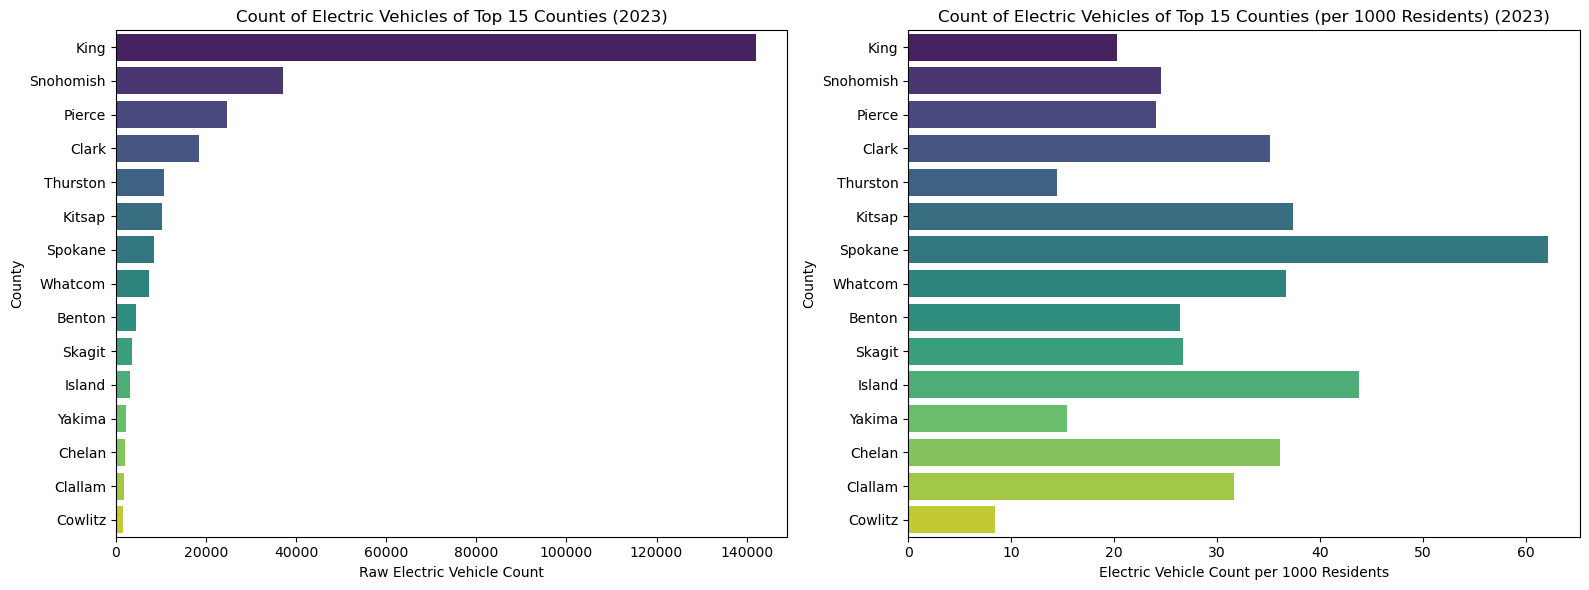

In [27]:


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Raw counts
sns.barplot(x=count_vehicle_county.values, y=count_vehicle_county.index, hue=count_vehicle_county.index, 
            palette='viridis', ax=axes[0])  # left subplot
        
axes[0].set_xlabel('Raw Electric Vehicle Count')
axes[0].set_ylabel('County')
axes[0].set_title('Count of Electric Vehicles of Top 15 Counties (2023)')

# Right plot: Per capita rate
sns.barplot(x=df_merged['EV_per_1000'], y=df_merged_sort['County'], hue=df_merged_sort['County'], 
            palette='viridis', ax=axes[1], legend=False)  #right subplot
        
axes[1].set_xlabel('Electric Vehicle Count per 1000 Residents')
axes[1].set_ylabel('County')
axes[1].set_title('Count of Electric Vehicles of Top 15 Counties (per 1000 Residents) (2023)')

plt.tight_layout()
plt.show()

## Social Characteristics

In [28]:
soc_chars = pd.read_csv('soc_chars_wa_county.csv')
soc_chars.head(5)

,GEO_ID,NAME,DP02_0001E,DP02_0001M,DP02_0002E,DP02_0002M,DP02_0003E,DP02_0003M,DP02_0004E,DP02_0004M,...,DP02_0150PM,DP02_0151PE,DP02_0151PM,DP02_0152PE,DP02_0152PM,DP02_0153PE,DP02_0153PM,DP02_0154PE,DP02_0154PM,Unnamed: 618
0,Geography,Geographic Area Name,Estimate!!HOUSEHOLDS BY TYPE!!Total households,Margin of Error!!HOUSEHOLDS BY TYPE!!Total hou...,Estimate!!HOUSEHOLDS BY TYPE!!Total households...,Margin of Error!!HOUSEHOLDS BY TYPE!!Total hou...,Estimate!!HOUSEHOLDS BY TYPE!!Total households...,Margin of Error!!HOUSEHOLDS BY TYPE!!Total hou...,Estimate!!HOUSEHOLDS BY TYPE!!Total households...,Margin of Error!!HOUSEHOLDS BY TYPE!!Total hou...,...,Percent Margin of Error!!ANCESTRY!!Total popul...,Percent!!ANCESTRY!!Total population!!West Indi...,Percent Margin of Error!!ANCESTRY!!Total popul...,Percent!!COMPUTERS AND INTERNET USE!!Total hou...,Percent Margin of Error!!COMPUTERS AND INTERNE...,Percent!!COMPUTERS AND INTERNET USE!!Total hou...,Percent Margin of Error!!COMPUTERS AND INTERNE...,Percent!!COMPUTERS AND INTERNET USE!!Total hou...,Percent Margin of Error!!COMPUTERS AND INTERNE...,NaN
1,0400000US53,Washington,3020558,5770,1492088,9081,591354,6673,259700,4372,...,0.1,0.2,0.1,3020558,(X),96.7,0.1,93.0,0.1,NaN
2,0500000US53001,"Adams County, Washington",6301,166,3572,307,1730,332,461,129,...,0.1,0.2,0.3,6301,(X),91.7,2.6,87.4,3.2,NaN
3,0500000US53003,"Asotin County, Washington",9438,220,4058,272,1125,182,945,199,...,0.4,0.0,0.2,9438,(X),95.1,1.4,87.0,2.6,NaN
4,0500000US53005,"Benton County, Washington",76696,603,38991,975,15438,825,6505,677,...,0.3,0.2,0.1,76696,(X),96.1,0.6,91.8,0.9,NaN


In [29]:
df_chars = soc_chars[soc_chars['NAME'].str.contains('County', na=False) | (soc_chars.index == 0)].copy()
df_chars = df_chars.rename(columns={'NAME': 'County'})
df_chars['County'] = df_chars['County'].str.replace(' County, Washington', '', regex=False) 

df_chars.head(5)

,GEO_ID,County,DP02_0001E,DP02_0001M,DP02_0002E,DP02_0002M,DP02_0003E,DP02_0003M,DP02_0004E,DP02_0004M,...,DP02_0150PM,DP02_0151PE,DP02_0151PM,DP02_0152PE,DP02_0152PM,DP02_0153PE,DP02_0153PM,DP02_0154PE,DP02_0154PM,Unnamed: 618
0,Geography,Geographic Area Name,Estimate!!HOUSEHOLDS BY TYPE!!Total households,Margin of Error!!HOUSEHOLDS BY TYPE!!Total hou...,Estimate!!HOUSEHOLDS BY TYPE!!Total households...,Margin of Error!!HOUSEHOLDS BY TYPE!!Total hou...,Estimate!!HOUSEHOLDS BY TYPE!!Total households...,Margin of Error!!HOUSEHOLDS BY TYPE!!Total hou...,Estimate!!HOUSEHOLDS BY TYPE!!Total households...,Margin of Error!!HOUSEHOLDS BY TYPE!!Total hou...,...,Percent Margin of Error!!ANCESTRY!!Total popul...,Percent!!ANCESTRY!!Total population!!West Indi...,Percent Margin of Error!!ANCESTRY!!Total popul...,Percent!!COMPUTERS AND INTERNET USE!!Total hou...,Percent Margin of Error!!COMPUTERS AND INTERNE...,Percent!!COMPUTERS AND INTERNET USE!!Total hou...,Percent Margin of Error!!COMPUTERS AND INTERNE...,Percent!!COMPUTERS AND INTERNET USE!!Total hou...,Percent Margin of Error!!COMPUTERS AND INTERNE...,NaN
2,0500000US53001,Adams,6301,166,3572,307,1730,332,461,129,...,0.1,0.2,0.3,6301,(X),91.7,2.6,87.4,3.2,NaN
3,0500000US53003,Asotin,9438,220,4058,272,1125,182,945,199,...,0.4,0.0,0.2,9438,(X),95.1,1.4,87.0,2.6,NaN
4,0500000US53005,Benton,76696,603,38991,975,15438,825,6505,677,...,0.3,0.2,0.1,76696,(X),96.1,0.6,91.8,0.9,NaN
5,0500000US53007,Chelan,30825,495,15758,760,6005,515,2418,447,...,0.3,0.0,0.1,30825,(X),95.0,1.1,89.6,1.4,NaN


In [30]:
#print(type(df_chars))

In [31]:
words_to_drop = ['computers', 'household']

cols_to_keep = [col for col in df_chars.columns
    if col in ['County', 'GEO_ID'] or not any(word.lower() in str(df_chars.loc[0, col]).lower() 
        for word in words_to_drop)]

df_char_filt = df_chars[cols_to_keep].copy()

df_char_filt.head(5)

,GEO_ID,County,DP02_0025E,DP02_0025M,DP02_0026E,DP02_0026M,DP02_0027E,DP02_0027M,DP02_0028E,DP02_0028M,...,DP02_0147PM,DP02_0148PE,DP02_0148PM,DP02_0149PE,DP02_0149PM,DP02_0150PE,DP02_0150PM,DP02_0151PE,DP02_0151PM,Unnamed: 618
0,Geography,Geographic Area Name,Estimate!!MARITAL STATUS!!Males 15 years and over,Margin of Error!!MARITAL STATUS!!Males 15 year...,Estimate!!MARITAL STATUS!!Males 15 years and o...,Margin of Error!!MARITAL STATUS!!Males 15 year...,Estimate!!MARITAL STATUS!!Males 15 years and o...,Margin of Error!!MARITAL STATUS!!Males 15 year...,Estimate!!MARITAL STATUS!!Males 15 years and o...,Margin of Error!!MARITAL STATUS!!Males 15 year...,...,Percent Margin of Error!!ANCESTRY!!Total popul...,Percent!!ANCESTRY!!Total population!!Swiss,Percent Margin of Error!!ANCESTRY!!Total popul...,Percent!!ANCESTRY!!Total population!!Ukrainian,Percent Margin of Error!!ANCESTRY!!Total popul...,Percent!!ANCESTRY!!Total population!!Welsh,Percent Margin of Error!!ANCESTRY!!Total popul...,Percent!!ANCESTRY!!Total population!!West Indi...,Percent Margin of Error!!ANCESTRY!!Total popul...,NaN
2,0500000US53001,Adams,7521,114,2811,257,3912,317,111,72,...,0.4,0.0,0.2,0.0,0.2,0.2,0.1,0.2,0.3,NaN
3,0500000US53003,Asotin,9236,122,2906,253,4184,297,153,98,...,0.9,0.3,0.2,0.0,0.2,0.8,0.4,0.0,0.2,NaN
4,0500000US53005,Benton,82329,154,29229,955,42275,1072,844,259,...,0.3,0.3,0.1,0.3,0.1,1.2,0.3,0.2,0.1,NaN
5,0500000US53007,Chelan,32290,149,10538,680,17473,800,199,78,...,0.5,0.3,0.1,0.3,0.1,1.0,0.3,0.0,0.1,NaN


In [32]:
# dropping ancestry since going to merge with another dataset for  

words_to_drop = ['computers', 'household', 'marital', 'fertility', 'grandparents', 'enrollment', 'disability', 'residence', 
                'region', 'entry', 'percent', 'ancestry', 'margin', 'veteran', 'birth', 'nan'] 
#if these show up in the dataset, the corresponding column will get dropped

cols_to_keep = [col for col in df_char_filt.columns
    if col in ['County', 'GEO_ID'] or not any(word.lower() in str(df_char_filt.loc[0, col]).lower() 
        for word in words_to_drop)]

df_char_filt = df_char_filt[cols_to_keep].copy()

df_char_filt.head(5)

,GEO_ID,County,DP02_0059E,DP02_0060E,DP02_0061E,DP02_0062E,DP02_0063E,DP02_0064E,DP02_0065E,DP02_0066E,...,DP02_0114E,DP02_0115E,DP02_0116E,DP02_0117E,DP02_0118E,DP02_0119E,DP02_0120E,DP02_0121E,DP02_0122E,DP02_0123E
0,Geography,Geographic Area Name,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...
2,0500000US53001,Adams,11332,2510,897,3323,1989,865,1150,598,...,9698,4580,9211,4383,173,21,133,13,181,163
3,0500000US53003,Asotin,16393,412,906,5065,4085,1937,2428,1560,...,690,214,321,102,128,28,213,76,28,8
4,0500000US53005,Benton,136939,7280,6610,31534,31635,14724,27497,17659,...,41911,15853,32866,13070,4165,980,3490,1378,1390,425
5,0500000US53007,Chelan,55208,4400,3416,12905,12045,5758,10806,5878,...,19472,8080,17997,7739,878,96,551,245,46,0


In [33]:
for col in df_char_filt.columns:
    desc = df_char_filt.loc[0, col]
    print(f"{col:<15} | {desc}")

GEO_ID          | Geography
County          | Geographic Area Name
DP02_0059E      | Estimate!!EDUCATIONAL ATTAINMENT!!Population 25 years and over
DP02_0060E      | Estimate!!EDUCATIONAL ATTAINMENT!!Population 25 years and over!!Less than 9th grade
DP02_0061E      | Estimate!!EDUCATIONAL ATTAINMENT!!Population 25 years and over!!9th to 12th grade, no diploma
DP02_0062E      | Estimate!!EDUCATIONAL ATTAINMENT!!Population 25 years and over!!High school graduate (includes equivalency)
DP02_0063E      | Estimate!!EDUCATIONAL ATTAINMENT!!Population 25 years and over!!Some college, no degree
DP02_0064E      | Estimate!!EDUCATIONAL ATTAINMENT!!Population 25 years and over!!Associate's degree
DP02_0065E      | Estimate!!EDUCATIONAL ATTAINMENT!!Population 25 years and over!!Bachelor's degree
DP02_0066E      | Estimate!!EDUCATIONAL ATTAINMENT!!Population 25 years and over!!Graduate or professional degree
DP02_0067E      | Estimate!!EDUCATIONAL ATTAINMENT!!Population 25 years and over!!High scho

In [34]:
df_char_filt.head(10)

,GEO_ID,County,DP02_0059E,DP02_0060E,DP02_0061E,DP02_0062E,DP02_0063E,DP02_0064E,DP02_0065E,DP02_0066E,...,DP02_0114E,DP02_0115E,DP02_0116E,DP02_0117E,DP02_0118E,DP02_0119E,DP02_0120E,DP02_0121E,DP02_0122E,DP02_0123E
0,Geography,Geographic Area Name,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,Estimate!!EDUCATIONAL ATTAINMENT!!Population 2...,...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...,Estimate!!LANGUAGE SPOKEN AT HOME!!Population ...
2,0500000US53001,Adams,11332,2510,897,3323,1989,865,1150,598,...,9698,4580,9211,4383,173,21,133,13,181,163
3,0500000US53003,Asotin,16393,412,906,5065,4085,1937,2428,1560,...,690,214,321,102,128,28,213,76,28,8
4,0500000US53005,Benton,136939,7280,6610,31534,31635,14724,27497,17659,...,41911,15853,32866,13070,4165,980,3490,1378,1390,425
5,0500000US53007,Chelan,55208,4400,3416,12905,12045,5758,10806,5878,...,19472,8080,17997,7739,878,96,551,245,46,0
6,0500000US53009,Clallam,60562,1190,3055,15188,15208,7334,11064,7523,...,4232,1253,2142,725,1057,170,662,317,371,41
7,0500000US53011,Clark,351391,8875,16556,86129,86913,37098,73646,42174,...,78794,29203,33035,11871,25775,9283,17600,7593,2384,456
8,0500000US53013,Columbia,3097,126,217,694,807,410,496,347,...,283,190,193,133,36,10,54,47,0,0
9,0500000US53015,Cowlitz,77987,2655,5187,24505,22420,9957,8973,4290,...,8214,3223,5843,2360,1175,271,1190,592,6,0
10,0500000US53017,Douglas,29168,2748,2345,8273,6538,2887,4440,1937,...,11958,5657,11302,5461,400,76,240,120,16,0


In [35]:
df_char_filt.loc[0] = df_char_filt.loc[0].astype(str).str.replace(r'^.*!!', '', regex=True)
df_char_filt.loc[0] = df_char_filt.loc[0].str.replace('""', '', regex=False)

df_char_filt.head(10)

,GEO_ID,County,DP02_0059E,DP02_0060E,DP02_0061E,DP02_0062E,DP02_0063E,DP02_0064E,DP02_0065E,DP02_0066E,...,DP02_0114E,DP02_0115E,DP02_0116E,DP02_0117E,DP02_0118E,DP02_0119E,DP02_0120E,DP02_0121E,DP02_0122E,DP02_0123E
0,Geography,Geographic Area Name,Population 25 years and over,Less than 9th grade,"9th to 12th grade, no diploma",High school graduate (includes equivalency),"Some college, no degree",Associate's degree,Bachelor's degree,Graduate or professional degree,...,Language other than English,Speak English less than very well,Spanish,Speak English less than very well,Other Indo-European languages,Speak English less than very well,Asian and Pacific Islander languages,Speak English less than very well,Other languages,Speak English less than very well
2,0500000US53001,Adams,11332,2510,897,3323,1989,865,1150,598,...,9698,4580,9211,4383,173,21,133,13,181,163
3,0500000US53003,Asotin,16393,412,906,5065,4085,1937,2428,1560,...,690,214,321,102,128,28,213,76,28,8
4,0500000US53005,Benton,136939,7280,6610,31534,31635,14724,27497,17659,...,41911,15853,32866,13070,4165,980,3490,1378,1390,425
5,0500000US53007,Chelan,55208,4400,3416,12905,12045,5758,10806,5878,...,19472,8080,17997,7739,878,96,551,245,46,0
6,0500000US53009,Clallam,60562,1190,3055,15188,15208,7334,11064,7523,...,4232,1253,2142,725,1057,170,662,317,371,41
7,0500000US53011,Clark,351391,8875,16556,86129,86913,37098,73646,42174,...,78794,29203,33035,11871,25775,9283,17600,7593,2384,456
8,0500000US53013,Columbia,3097,126,217,694,807,410,496,347,...,283,190,193,133,36,10,54,47,0,0
9,0500000US53015,Cowlitz,77987,2655,5187,24505,22420,9957,8973,4290,...,8214,3223,5843,2360,1175,271,1190,592,6,0
10,0500000US53017,Douglas,29168,2748,2345,8273,6538,2887,4440,1937,...,11958,5657,11302,5461,400,76,240,120,16,0


### Educational Attainment

In [36]:
col1 = 'DP02_0060E'  # Less than 9th grade
col2 = 'DP02_0061E'  # 9th to 12th grade, no diploma

# Sum the columns for data rows (rows where index != 0)
numeric_sum = (pd.to_numeric(df_char_filt.loc[1:, col1], errors='coerce') + 
    pd.to_numeric(df_char_filt.loc[1:, col2], errors='coerce'))


col_position = df_char_filt.columns.get_loc(col1)

# Insert the new column at that original position to keep order
df_char_filt.insert(loc=col_position, column='no_hs_diploma', value=None)

# Create the new merged column with its description in Row 0
df_char_filt['no_hs_diploma'] = None
df_char_filt.loc[0, 'no_hs_diploma'] = 'Less than High School Diploma'  # Label for Row 0
df_char_filt.loc[1:, 'no_hs_diploma'] = numeric_sum

# Drop the original individual columns
df_char_filt = df_char_filt.drop(columns=[col1, col2])

df_char_filt.head(5)

,GEO_ID,County,DP02_0059E,no_hs_diploma,DP02_0062E,DP02_0063E,DP02_0064E,DP02_0065E,DP02_0066E,DP02_0067E,...,DP02_0114E,DP02_0115E,DP02_0116E,DP02_0117E,DP02_0118E,DP02_0119E,DP02_0120E,DP02_0121E,DP02_0122E,DP02_0123E
0,Geography,Geographic Area Name,Population 25 years and over,Less than High School Diploma,High school graduate (includes equivalency),"Some college, no degree",Associate's degree,Bachelor's degree,Graduate or professional degree,High school graduate or higher,...,Language other than English,Speak English less than very well,Spanish,Speak English less than very well,Other Indo-European languages,Speak English less than very well,Asian and Pacific Islander languages,Speak English less than very well,Other languages,Speak English less than very well
2,0500000US53001,Adams,11332,3407,3323,1989,865,1150,598,7925,...,9698,4580,9211,4383,173,21,133,13,181,163
3,0500000US53003,Asotin,16393,1318,5065,4085,1937,2428,1560,15075,...,690,214,321,102,128,28,213,76,28,8
4,0500000US53005,Benton,136939,13890,31534,31635,14724,27497,17659,123049,...,41911,15853,32866,13070,4165,980,3490,1378,1390,425
5,0500000US53007,Chelan,55208,7816,12905,12045,5758,10806,5878,47392,...,19472,8080,17997,7739,878,96,551,245,46,0


In [37]:
df_char_filt = df_char_filt.drop(columns=['DP02_0115E', 'DP02_0117E', 'DP02_0119E', 
                                          'DP02_0121E', 'DP02_0123E', 'DP02_0067E']) 
#language speak less than well and hs or higher
df_char_filt.head(5)

,GEO_ID,County,DP02_0059E,no_hs_diploma,DP02_0062E,DP02_0063E,DP02_0064E,DP02_0065E,DP02_0066E,DP02_0068E,DP02_0095E,DP02_0096E,DP02_0097E,DP02_0112E,DP02_0113E,DP02_0114E,DP02_0116E,DP02_0118E,DP02_0120E,DP02_0122E
0,Geography,Geographic Area Name,Population 25 years and over,Less than High School Diploma,High school graduate (includes equivalency),"Some college, no degree",Associate's degree,Bachelor's degree,Graduate or professional degree,Bachelor's degree or higher,Foreign-born population,Naturalized U.S. citizen,Not a U.S. citizen,Population 5 years and over,English only,Language other than English,Spanish,Other Indo-European languages,Asian and Pacific Islander languages,Other languages
2,0500000US53001,Adams,11332,3407,3323,1989,865,1150,598,1748,4783,1091,3692,18880,9182,9698,9211,173,133,181
3,0500000US53003,Asotin,16393,1318,5065,4085,1937,2428,1560,3988,560,211,349,21140,20450,690,321,128,213,28
4,0500000US53005,Benton,136939,13890,31534,31635,14724,27497,17659,45156,23647,9770,13877,196594,154683,41911,32866,4165,3490,1390
5,0500000US53007,Chelan,55208,7816,12905,12045,5758,10806,5878,16684,11314,3795,7519,75077,55605,19472,17997,878,551,46


In [38]:
col1 = 'DP02_0064E'  # Associates deg
col2 = 'DP02_0065E'  # Bach deg

# Sum the columns for data rows (rows where index != 0)
numeric_sum = (pd.to_numeric(df_char_filt.loc[1:, col1], errors='coerce') + 
    pd.to_numeric(df_char_filt.loc[1:, col2], errors='coerce'))


col_position = df_char_filt.columns.get_loc(col1)

# Insert the new column at that original position to keep order
df_char_filt.insert(loc=col_position, column='associates_bach', value=None)

# Create the new merged column with its description in Row 0
df_char_filt['associates_bach'] = None
df_char_filt.loc[0, 'associates_bach'] = 'Associates or Bachelors degree'  # Label for Row 0
df_char_filt.loc[1:, 'associates_bach'] = numeric_sum

# Drop the original individual columns
df_char_filt = df_char_filt.drop(columns=[col1, col2])

df_char_filt.head(5)

,GEO_ID,County,DP02_0059E,no_hs_diploma,DP02_0062E,DP02_0063E,associates_bach,DP02_0066E,DP02_0068E,DP02_0095E,DP02_0096E,DP02_0097E,DP02_0112E,DP02_0113E,DP02_0114E,DP02_0116E,DP02_0118E,DP02_0120E,DP02_0122E
0,Geography,Geographic Area Name,Population 25 years and over,Less than High School Diploma,High school graduate (includes equivalency),"Some college, no degree",Associates or Bachelors degree,Graduate or professional degree,Bachelor's degree or higher,Foreign-born population,Naturalized U.S. citizen,Not a U.S. citizen,Population 5 years and over,English only,Language other than English,Spanish,Other Indo-European languages,Asian and Pacific Islander languages,Other languages
2,0500000US53001,Adams,11332,3407,3323,1989,2015,598,1748,4783,1091,3692,18880,9182,9698,9211,173,133,181
3,0500000US53003,Asotin,16393,1318,5065,4085,4365,1560,3988,560,211,349,21140,20450,690,321,128,213,28
4,0500000US53005,Benton,136939,13890,31534,31635,42221,17659,45156,23647,9770,13877,196594,154683,41911,32866,4165,3490,1390
5,0500000US53007,Chelan,55208,7816,12905,12045,16564,5878,16684,11314,3795,7519,75077,55605,19472,17997,878,551,46


In [39]:
for col in df_char_filt.columns:
    desc = df_char_filt.loc[0, col]
    print(f"{col:<15} | {desc}")

GEO_ID          | Geography
County          | Geographic Area Name
DP02_0059E      | Population 25 years and over
no_hs_diploma   | Less than High School Diploma
DP02_0062E      | High school graduate (includes equivalency)
DP02_0063E      | Some college, no degree
associates_bach | Associates or Bachelors degree
DP02_0066E      | Graduate or professional degree
DP02_0068E      | Bachelor's degree or higher
DP02_0095E      | Foreign-born population
DP02_0096E      | Naturalized U.S. citizen
DP02_0097E      | Not a U.S. citizen
DP02_0112E      | Population 5 years and over
DP02_0113E      | English only
DP02_0114E      | Language other than English
DP02_0116E      | Spanish
DP02_0118E      | Other Indo-European languages
DP02_0120E      | Asian and Pacific Islander languages
DP02_0122E      | Other languages


In [40]:
# use percentages instead of row counts because of the difference in populations through counties

edu_percent_county = df_char_filt.loc[1:].copy()
edu_cols = ['no_hs_diploma', 'DP02_0062E', 'DP02_0063E', 'associates_bach', 'DP02_0066E'] #these are raw
pop_col = 'DP02_0059E'  # Total population 25 years and over

all_cols = edu_cols + [pop_col]
for col in all_cols:
    edu_percent_county[col] = pd.to_numeric(edu_percent_county[col], errors='coerce')

pct_cols = []
for col in edu_cols:
    pct_col_name = f"{col}_pct"
    edu_percent_county[pct_col_name] = (edu_percent_county[col] / edu_percent_county[pop_col]) * 100
    pct_cols.append(pct_col_name)

# higher ed
edu_percent_county['higher_ed_pct'] = edu_percent_county['associates_bach_pct'] + edu_percent_county['DP02_0066E_pct']
edu_percent_county = edu_percent_county.sort_values('higher_ed_pct', ascending=True)

edu_percent_county.head(5)

,GEO_ID,County,DP02_0059E,no_hs_diploma,DP02_0062E,DP02_0063E,associates_bach,DP02_0066E,DP02_0068E,DP02_0095E,...,DP02_0116E,DP02_0118E,DP02_0120E,DP02_0122E,no_hs_diploma_pct,DP02_0062E_pct,DP02_0063E_pct,associates_bach_pct,DP02_0066E_pct,higher_ed_pct
2,0500000US53001,Adams,11332,3407,3323,1989,2015,598,1748,4783,...,9211,173,133,181,30.1,29.3,17.6,17.8,5.3,23.1
40,0500000US53077,Yakima,157100,37206,45967,30997,32237,10693,29637,47572,...,97179,1305,2000,900,23.7,29.3,19.7,20.5,6.8,27.3
14,0500000US53025,Grant,61989,11520,18004,14654,14546,3265,11260,16247,...,31255,1328,441,119,18.6,29.0,23.6,23.5,5.3,28.7
9,0500000US53015,Cowlitz,77987,7842,24505,22420,18930,4290,13263,4576,...,5843,1175,1190,6,10.1,31.4,28.7,24.3,5.5,29.8
15,0500000US53027,Grays Harbor,56001,5409,19743,14129,13313,3407,9868,3936,...,4885,832,782,324,9.7,35.3,25.2,23.8,6.1,29.9


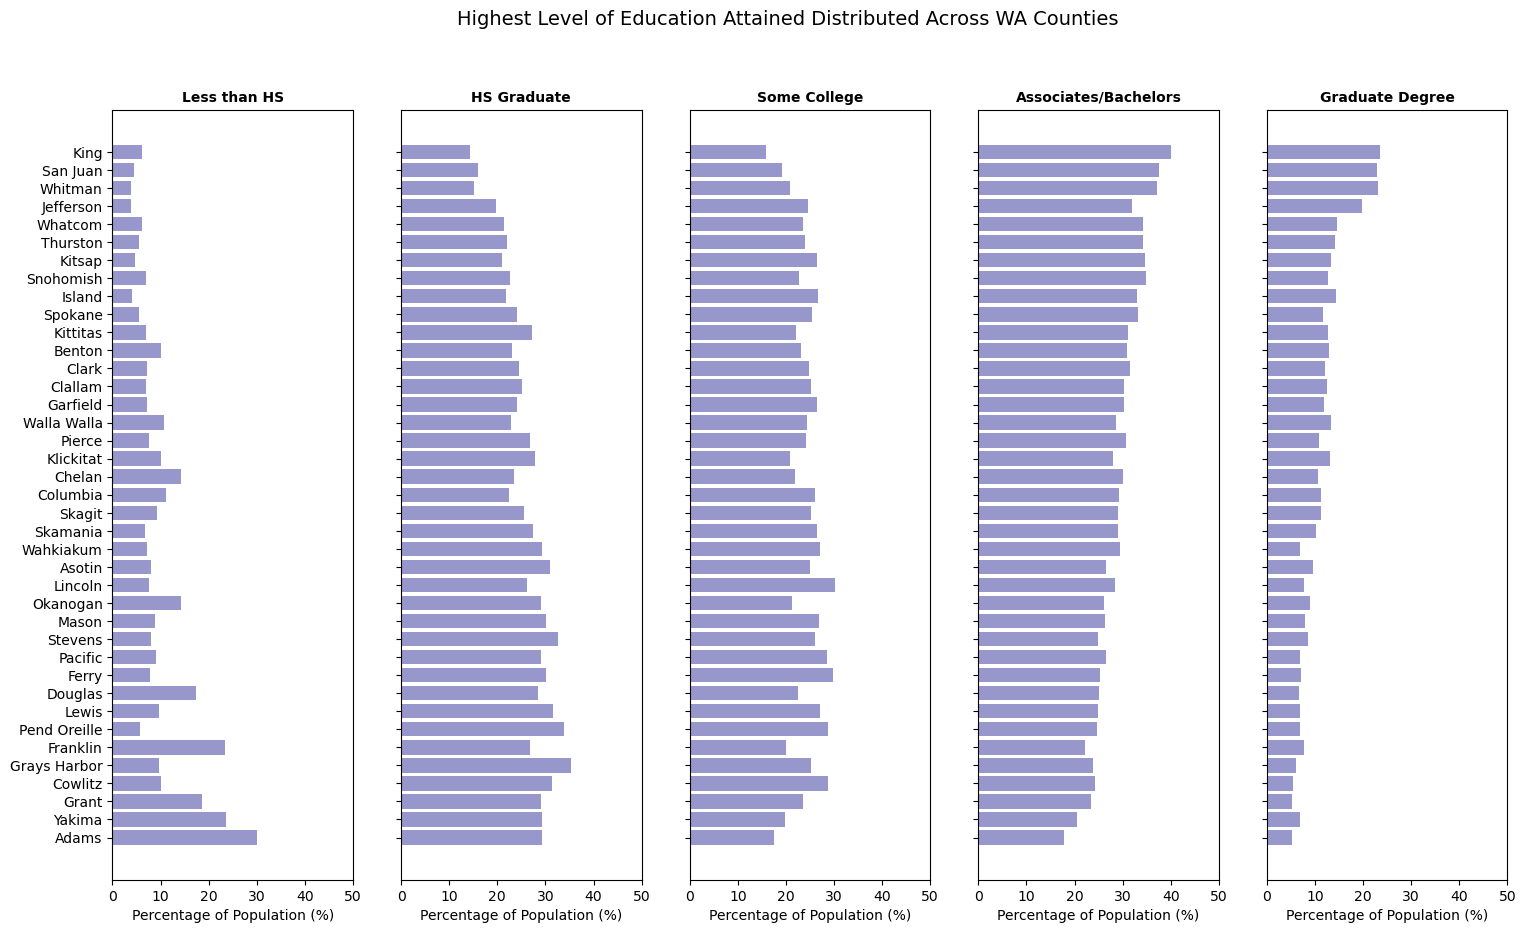

In [71]:
# bar plot

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(18, 10), sharey=True)
categories = ['Less than HS', 'HS Graduate', 'Some College', 'Associates/Bachelors', 'Graduate Degree']

# plot the percent cols of edu pop and couties across the five categories above, making 5 different graphs

for i, (col, title) in enumerate(zip(pct_cols, categories)):
    axes[i].barh(edu_percent_county['County'], edu_percent_county[col], color='#9897CB', edgecolor='none')
    axes[i].set_title(title, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Percentage of Population (%)')
    axes[i].set_xlim(0, 50)



plt.suptitle('Highest Level of Education Attained Distributed Across WA Counties', fontsize=14)
plt.show()

In [42]:
counties_to_keep = ['King', 'Snohomish', 'Pierce', 'Clark', 'Thurston', 'Kitsap', 
                    'Spokane', 'Whatcom', 'Benton', 'Skagit', 'Island', 'Yakima', 
                    'Chelan', 'Clallam', 'Cowlitz']

edu_percent_top_counties = edu_percent_county[edu_percent_county['County'].isin(counties_to_keep)].copy()
edu_percent_top_counties['County'] = pd.Categorical(edu_percent_top_counties['County'], categories=counties_to_keep, ordered=True)

edu_percent_top_counties = edu_percent_top_counties.sort_values(by='County').reset_index(drop=True)

edu_percent_top_counties

,GEO_ID,County,DP02_0059E,no_hs_diploma,DP02_0062E,DP02_0063E,associates_bach,DP02_0066E,DP02_0068E,DP02_0095E,...,DP02_0116E,DP02_0118E,DP02_0120E,DP02_0122E,no_hs_diploma_pct,DP02_0062E_pct,DP02_0063E_pct,associates_bach_pct,DP02_0066E_pct,higher_ed_pct
0,0500000US53033,King,1634473,101640,233689,260454,654373,384317,914159,568300,...,150694,159390,273483,62004,6.2,14.3,15.9,40.0,23.5,63.5
1,0500000US53061,Snohomish,586955,40641,133414,133792,204873,74235,216250,154659,...,57988,43812,66592,17658,6.9,22.7,22.8,34.9,12.6,47.6
2,0500000US53053,Pierce,628616,47340,167958,152057,192665,68596,189514,97273,...,56608,25835,46976,7477,7.5,26.7,24.2,30.6,10.9,41.6
3,0500000US53011,Clark,351391,25431,86129,86913,110744,42174,115820,56157,...,33035,25775,17600,2384,7.2,24.5,24.7,31.5,12.0,43.5
4,0500000US53067,Thurston,211430,11691,46768,50694,72268,30009,78600,25144,...,13320,6428,13273,1523,5.5,22.1,24.0,34.2,14.2,48.4
5,0500000US53035,Kitsap,196424,9205,41363,51958,67871,26027,71744,18859,...,8938,3712,9308,1071,4.7,21.1,26.5,34.6,13.3,47.8
6,0500000US53063,Spokane,377147,20698,91088,96214,125047,44100,121064,29302,...,12275,13202,9234,3997,5.5,24.2,25.5,33.2,11.7,44.8
7,0500000US53073,Whatcom,155393,9684,33192,36686,53090,22741,59183,22573,...,13913,7157,4885,1589,6.2,21.4,23.6,34.2,14.6,48.8
8,0500000US53005,Benton,136939,13890,31534,31635,42221,17659,45156,23647,...,32866,4165,3490,1390,10.1,23.0,23.1,30.8,12.9,43.7
9,0500000US53057,Skagit,93496,8570,23861,23488,27133,10444,27240,12180,...,16116,1979,1582,364,9.2,25.5,25.1,29.0,11.2,40.2


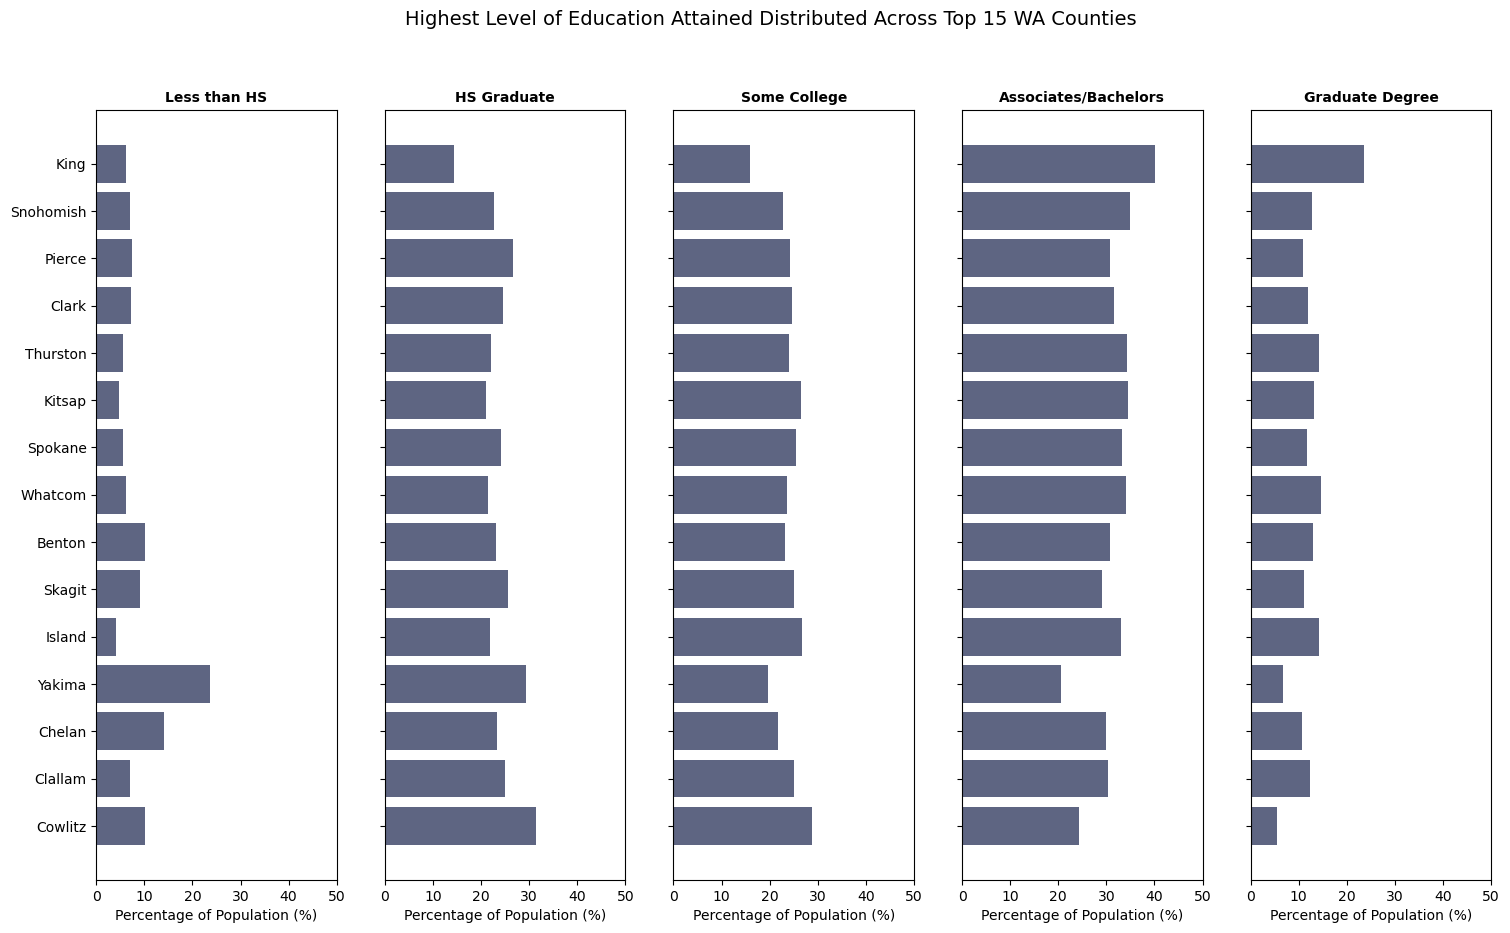

In [70]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(18, 10), sharey=True)
categories = ['Less than HS', 'HS Graduate', 'Some College', 'Associates/Bachelors', 'Graduate Degree']

# plot the percent cols of edu pop and couties across the five categories above, making 5 different graphs

for i, (col, title) in enumerate(zip(pct_cols, categories)):
    axes[i].barh(edu_percent_top_counties['County'], edu_percent_top_counties[col], color='#5E6582', edgecolor='none')
    axes[i].set_title(title, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Percentage of Population (%)')
    axes[i].set_xlim(0, 50)

axes[0].invert_yaxis()

# same counties from top 15 above
plt.suptitle('Highest Level of Education Attained Distributed Across Top 15 WA Counties', fontsize=14)
plt.show()

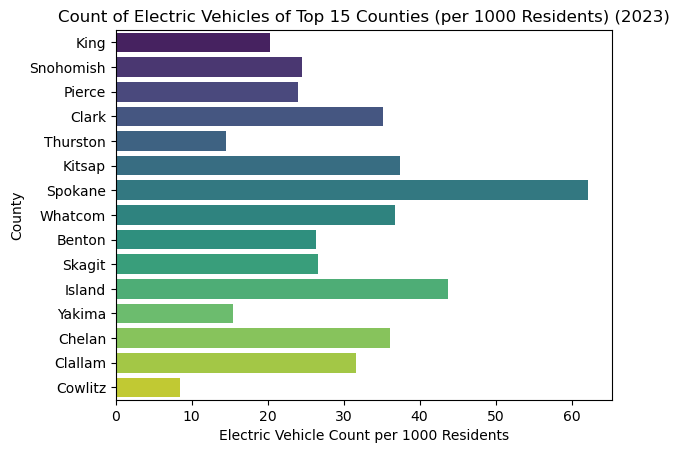

In [44]:
# graph copied from above for easier comparison
sns.barplot(x=df_merged['EV_per_1000'], y=df_merged_sort['County'], hue=df_merged_sort['County'], 
            palette='viridis', legend=False)  #right subplot
        
plt.xlabel('Electric Vehicle Count per 1000 Residents')
plt.ylabel('County')
plt.title('Count of Electric Vehicles of Top 15 Counties (per 1000 Residents) (2023)')
plt.show()

In [45]:
per_cols_keep = ['no_hs_diploma_pct', 'DP02_0062E_pct', # high school pct 
                 'DP02_0063E_pct', # some college 
                 'associates_bach_pct', 'DP02_0066E_pct', #grad or pro deg 
                 'higher_ed_pct'] 

edu_summary = edu_percent_top_counties[per_cols_keep].agg(['mean', 'std', 'min', 'max']).T 
edu_summary.index = ['Less than HS', 'HS Graduate', 'Some College', 'Associates/Bachelors', 'Graduate Degree', 'Higher Ed Total'] 
edu_summary = edu_summary.round(2) 
display(edu_summary)

,mean,std,min,max
Less than HS,8.6,4.9,4.1,23.7
HS Graduate,23.8,3.9,14.3,31.4
Some College,23.8,3.1,15.9,28.8
Associates/Bachelors,31.4,4.6,20.5,40.0
Graduate Degree,12.4,4.0,5.5,23.5
Higher Ed Total,43.9,8.3,27.3,63.5


In [46]:
df_char_filt.head(5)

,GEO_ID,County,DP02_0059E,no_hs_diploma,DP02_0062E,DP02_0063E,associates_bach,DP02_0066E,DP02_0068E,DP02_0095E,DP02_0096E,DP02_0097E,DP02_0112E,DP02_0113E,DP02_0114E,DP02_0116E,DP02_0118E,DP02_0120E,DP02_0122E
0,Geography,Geographic Area Name,Population 25 years and over,Less than High School Diploma,High school graduate (includes equivalency),"Some college, no degree",Associates or Bachelors degree,Graduate or professional degree,Bachelor's degree or higher,Foreign-born population,Naturalized U.S. citizen,Not a U.S. citizen,Population 5 years and over,English only,Language other than English,Spanish,Other Indo-European languages,Asian and Pacific Islander languages,Other languages
2,0500000US53001,Adams,11332,3407,3323,1989,2015,598,1748,4783,1091,3692,18880,9182,9698,9211,173,133,181
3,0500000US53003,Asotin,16393,1318,5065,4085,4365,1560,3988,560,211,349,21140,20450,690,321,128,213,28
4,0500000US53005,Benton,136939,13890,31534,31635,42221,17659,45156,23647,9770,13877,196594,154683,41911,32866,4165,3490,1390
5,0500000US53007,Chelan,55208,7816,12905,12045,16564,5878,16684,11314,3795,7519,75077,55605,19472,17997,878,551,46


### Citizenship

In [47]:
citizenship_df = df_char_filt.copy()
citizenship_df.head()

,GEO_ID,County,DP02_0059E,no_hs_diploma,DP02_0062E,DP02_0063E,associates_bach,DP02_0066E,DP02_0068E,DP02_0095E,DP02_0096E,DP02_0097E,DP02_0112E,DP02_0113E,DP02_0114E,DP02_0116E,DP02_0118E,DP02_0120E,DP02_0122E
0,Geography,Geographic Area Name,Population 25 years and over,Less than High School Diploma,High school graduate (includes equivalency),"Some college, no degree",Associates or Bachelors degree,Graduate or professional degree,Bachelor's degree or higher,Foreign-born population,Naturalized U.S. citizen,Not a U.S. citizen,Population 5 years and over,English only,Language other than English,Spanish,Other Indo-European languages,Asian and Pacific Islander languages,Other languages
2,0500000US53001,Adams,11332,3407,3323,1989,2015,598,1748,4783,1091,3692,18880,9182,9698,9211,173,133,181
3,0500000US53003,Asotin,16393,1318,5065,4085,4365,1560,3988,560,211,349,21140,20450,690,321,128,213,28
4,0500000US53005,Benton,136939,13890,31534,31635,42221,17659,45156,23647,9770,13877,196594,154683,41911,32866,4165,3490,1390
5,0500000US53007,Chelan,55208,7816,12905,12045,16564,5878,16684,11314,3795,7519,75077,55605,19472,17997,878,551,46


In [48]:
# keep cols with citizenship and drop others
# index 9 up to (but not including) index 12 and keep county names
citizenship_df = citizenship_df.iloc[:, np.r_[1:3, 9:12]]
citizenship_df.head()

,County,DP02_0059E,DP02_0095E,DP02_0096E,DP02_0097E
0,Geographic Area Name,Population 25 years and over,Foreign-born population,Naturalized U.S. citizen,Not a U.S. citizen
2,Adams,11332,4783,1091,3692
3,Asotin,16393,560,211,349
4,Benton,136939,23647,9770,13877
5,Chelan,55208,11314,3795,7519


In [49]:
citizenship_df = citizenship_df.rename(columns={'DP02_0059E': 'Population (Age 25 and older)', 
                                                'DP02_0095E': 'Foreign-born Population', 
                                               'DP02_0096E': 'Naturalized U.S. Citizen', 
                                               'DP02_0097E': 'Not a U.S. Citizen'})
citizenship_df.head(5)

,County,Population (Age 25 and older),Foreign-born Population,Naturalized U.S. Citizen,Not a U.S. Citizen
0,Geographic Area Name,Population 25 years and over,Foreign-born population,Naturalized U.S. citizen,Not a U.S. citizen
2,Adams,11332,4783,1091,3692
3,Asotin,16393,560,211,349
4,Benton,136939,23647,9770,13877
5,Chelan,55208,11314,3795,7519


In [50]:
print(citizenship_df.columns.tolist())

['County', 'Population (Age 25 and older)', 'Foreign-born Population', 'Naturalized U.S. Citizen', 'Not a U.S. Citizen']


Refer to the top of the document for more information on Citizenship Status Categories. 

In [51]:
raw_cit_cols = ['Foreign-born Population',
                'Naturalized U.S. Citizen', 
                'Not a U.S. Citizen']

pop_col = 'Population (Age 25 and older)'  # Or Total Population column if applicable

cit_clean = citizenship_df.iloc[1:].copy()

for col in raw_cit_cols + [pop_col]:
    cit_clean[col] = pd.to_numeric(cit_clean[col], errors='coerce')

cit_pct_cols = []
for col in raw_cit_cols:
    pct_col_name = f"{col} (%)"
    cit_clean[pct_col_name] = (cit_clean[col] / cit_clean[pop_col]) * 100
    cit_pct_cols.append(pct_col_name)

cit_clean.head(5)

,County,Population (Age 25 and older),Foreign-born Population,Naturalized U.S. Citizen,Not a U.S. Citizen,Foreign-born Population (%),Naturalized U.S. Citizen (%),Not a U.S. Citizen (%)
2,Adams,11332,4783,1091,3692,42.2,9.6,32.6
3,Asotin,16393,560,211,349,3.4,1.3,2.1
4,Benton,136939,23647,9770,13877,17.3,7.1,10.1
5,Chelan,55208,11314,3795,7519,20.5,6.9,13.6
6,Clallam,60562,3510,2335,1175,5.8,3.9,1.9


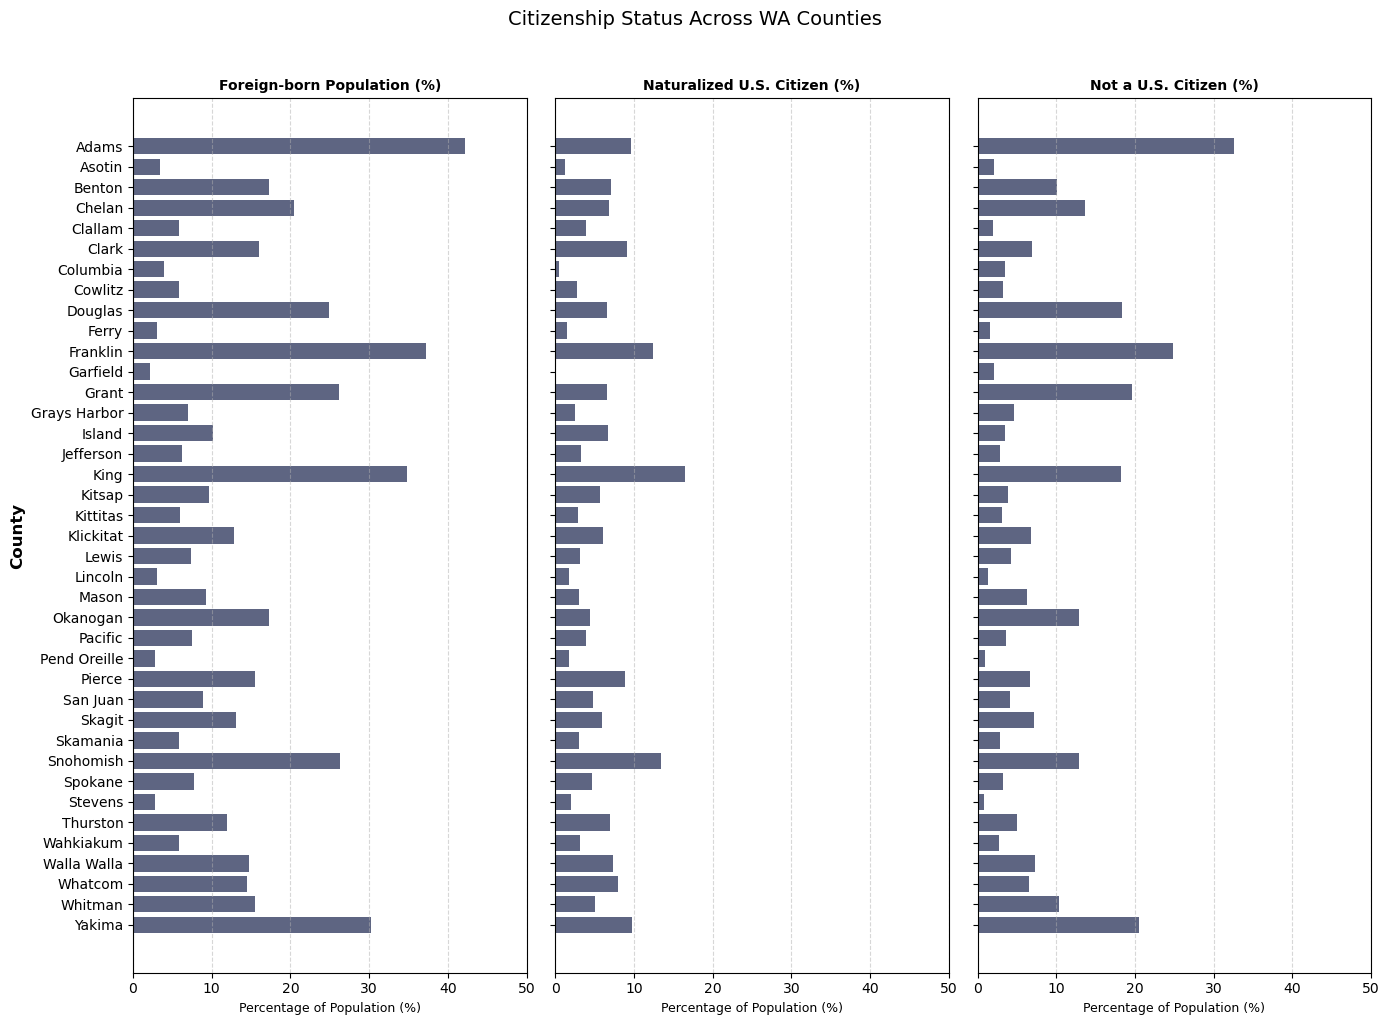

In [72]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 10), sharey=True)

categories = ['Foreign-born Population (%)', 
              'Naturalized U.S. Citizen (%)', 
              'Not a U.S. Citizen (%)']

# Iterate through cit_pct_cols (the list of column names)
for i, (col, title) in enumerate(zip(cit_pct_cols, categories)):
    axes[i].barh(cit_clean['County'], cit_clean[col], color='#5E6582', edgecolor='none')
    axes[i].set_title(title, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Percentage of Population (%)', fontsize=9)
    axes[i].set_xlim(0, 50)
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)

# flip axis
axes[0].invert_yaxis()

# Label Y-axis ONLY on the leftmost plot
axes[0].set_ylabel('County', fontsize=12, fontweight='bold')

plt.suptitle('Citizenship Status Across WA Counties', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [53]:
import pandas as pd

counties_to_keep = ['King', 'Snohomish', 'Pierce', 'Clark', 'Thurston', 'Kitsap', 
                    'Spokane', 'Whatcom', 'Benton', 'Skagit', 'Island', 'Yakima', 
                    'Chelan', 'Clallam', 'Cowlitz']

cit_percent_top_counties = cit_clean[cit_clean['County'].isin(counties_to_keep)].copy()

cit_percent_top_counties['County'] = pd.Categorical(cit_percent_top_counties['County'], categories=counties_to_keep, ordered=True)

cit_percent_top_counties = cit_percent_top_counties.sort_values(by='County').reset_index(drop=True)

cit_percent_top_counties

,County,Population (Age 25 and older),Foreign-born Population,Naturalized U.S. Citizen,Not a U.S. Citizen,Foreign-born Population (%),Naturalized U.S. Citizen (%),Not a U.S. Citizen (%)
0,King,1634473,568300,270107,298193,34.8,16.5,18.2
1,Snohomish,586955,154659,79152,75507,26.3,13.5,12.9
2,Pierce,628616,97273,55630,41643,15.5,8.8,6.6
3,Clark,351391,56157,31939,24218,16.0,9.1,6.9
4,Thurston,211430,25144,14657,10487,11.9,6.9,5.0
5,Kitsap,196424,18859,11196,7663,9.6,5.7,3.9
6,Spokane,377147,29302,17352,11950,7.8,4.6,3.2
7,Whatcom,155393,22573,12455,10118,14.5,8.0,6.5
8,Benton,136939,23647,9770,13877,17.3,7.1,10.1
9,Skagit,93496,12180,5509,6671,13.0,5.9,7.1


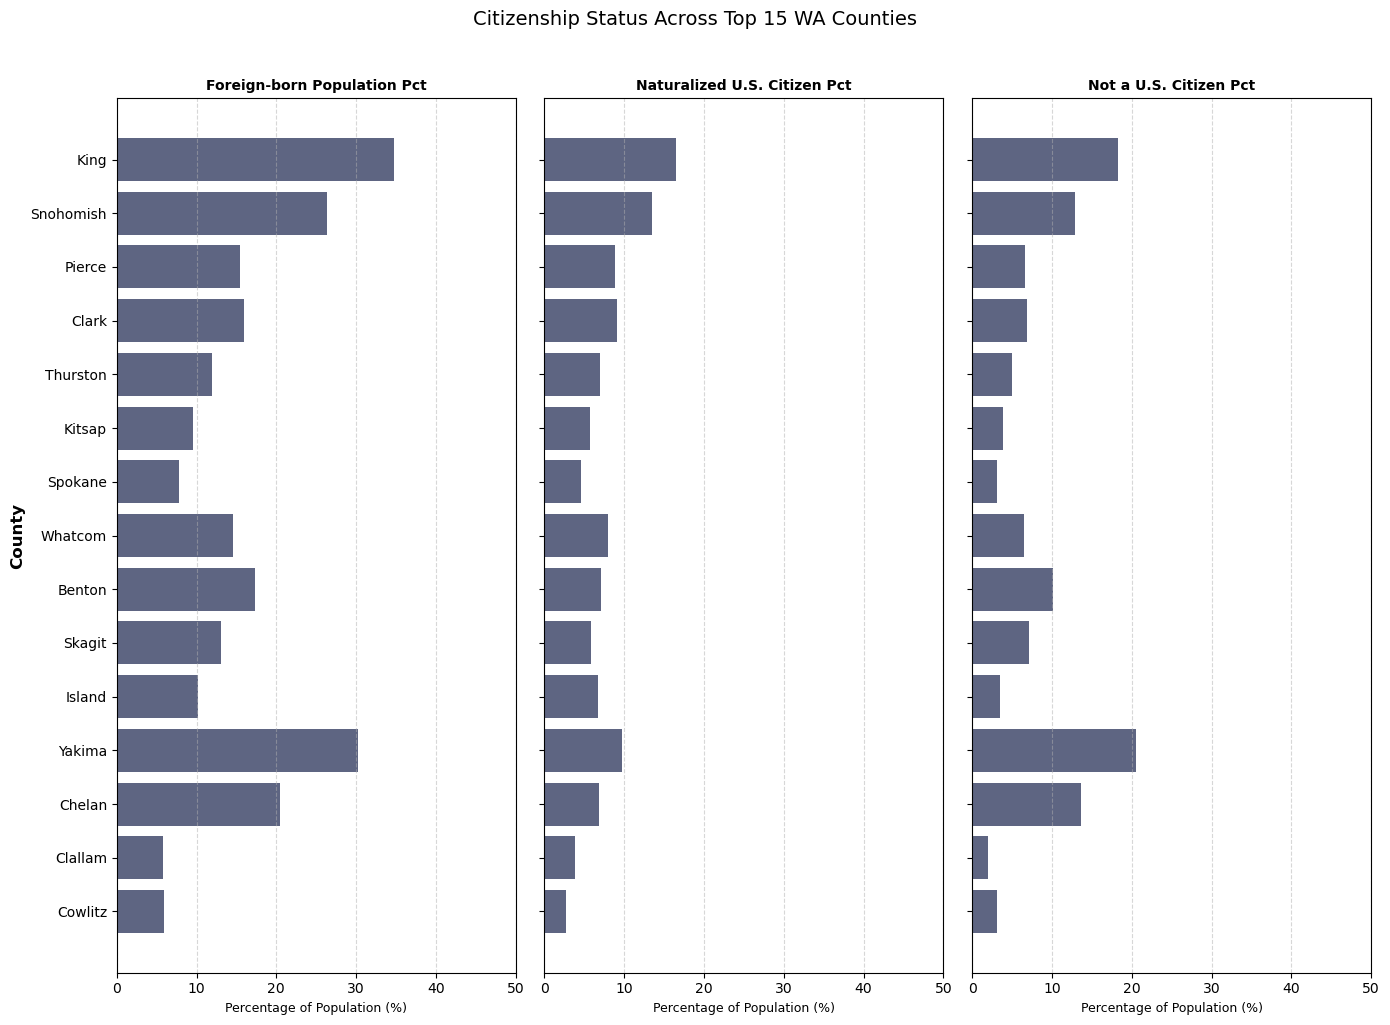

In [54]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 10), sharey=True)

categories = ['Foreign-born Population Pct', 
              'Naturalized U.S. Citizen Pct', 
              'Not a U.S. Citizen Pct']

# Iterate through cit_pct_cols (the list of column names)
for i, (col, title) in enumerate(zip(cit_pct_cols, categories)):
    axes[i].barh(cit_percent_top_counties['County'], cit_percent_top_counties[col], color='#5E6582', edgecolor='none')
    axes[i].set_title(title, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Percentage of Population (%)', fontsize=9)
    axes[i].set_xlim(0, 50)
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)

# flip axis
axes[0].invert_yaxis()

# Label Y-axis ONLY on the leftmost plot
axes[0].set_ylabel('County', fontsize=12, fontweight='bold')

plt.suptitle('Citizenship Status Across Top 15 WA Counties', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

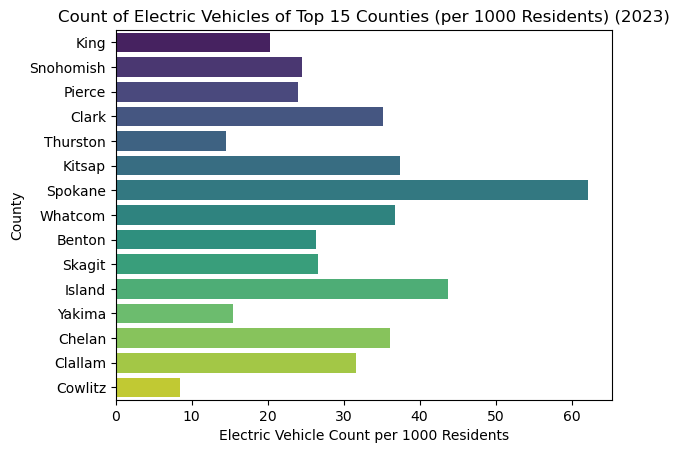

In [55]:
# graph copied from above for easier comparison
sns.barplot(x=df_merged['EV_per_1000'], y=df_merged_sort['County'], hue=df_merged_sort['County'], 
            palette='viridis', legend=False)  #right subplot
        
plt.xlabel('Electric Vehicle Count per 1000 Residents')
plt.ylabel('County')
plt.title('Count of Electric Vehicles of Top 15 Counties (per 1000 Residents) (2023)')
plt.show()

## Demographics

In [76]:
demo = pd.read_csv('demo_wa_county.csv')
demo.head(10)

,Label (Grouping),"Adams County, Washington!!Estimate","Adams County, Washington!!Margin of Error","Adams County, Washington!!Percent","Adams County, Washington!!Percent Margin of Error","Asotin County, Washington!!Estimate","Asotin County, Washington!!Margin of Error","Asotin County, Washington!!Percent","Asotin County, Washington!!Percent Margin of Error","Benton County, Washington!!Estimate",...,"Whatcom County, Washington!!Percent","Whatcom County, Washington!!Percent Margin of Error","Whitman County, Washington!!Estimate","Whitman County, Washington!!Margin of Error","Whitman County, Washington!!Percent","Whitman County, Washington!!Percent Margin of Error","Yakima County, Washington!!Estimate","Yakima County, Washington!!Margin of Error","Yakima County, Washington!!Percent","Yakima County, Washington!!Percent Margin of Error"
0,SEX AND AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total population,"20,690",*****,"20,690",(X),"22,424",*****,"22,424",(X),"210,224",...,"228,432",(X),"47,042",*****,"47,042",(X),"256,605",*****,"256,605",(X)
2,Male,"10,606",±97,51.3%,±0.5,"11,130",±128,49.6%,±0.6,"105,883",...,49.6%,±0.1,"23,857",±146,50.7%,±0.3,"128,666",±130,50.1%,±0.1
3,Female,"10,084",±97,48.7%,±0.5,"11,294",±128,50.4%,±0.6,"104,341",...,50.4%,±0.1,"23,185",±146,49.3%,±0.3,"127,939",±130,49.9%,±0.1
4,Sex ratio (males per 100 females),105.2,±2.0,(X),(X),98.5,±2.2,(X),(X),101.5,...,(X),(X),102.9,±1.3,(X),(X),100.6,±0.2,(X),(X)
5,Under 5 years,"1,810",±8,8.7%,±0.1,"1,284",±124,5.7%,±0.6,"13,630",...,4.7%,±0.1,"1,941",±17,4.1%,±0.1,"18,822",±122,7.3%,±0.1
6,5 to 9 years,"1,778",±274,8.6%,±1.3,930,±165,4.1%,±0.7,"16,667",...,5.5%,±0.3,"2,318",±201,4.9%,±0.4,"20,541",±844,8.0%,±0.3
7,10 to 14 years,"2,462",±270,11.9%,±1.3,"1,352",±178,6.0%,±0.8,"15,546",...,5.4%,±0.3,"1,806",±189,3.8%,±0.4,"22,827",±858,8.9%,±0.3
8,15 to 19 years,"1,908",±68,9.2%,±0.3,"1,277",±132,5.7%,±0.6,"14,686",...,6.4%,±0.1,"5,772",±212,12.3%,±0.5,"20,227",±94,7.9%,±0.1
9,20 to 24 years,"1,400",±43,6.8%,±0.2,"1,188",±110,5.3%,±0.5,"12,756",...,9.9%,±0.1,"10,848",±279,23.1%,±0.6,"17,088",±141,6.7%,±0.1


In [77]:
print(demo.shape)

(99, 157)


In [78]:
words_to_drop = ['margin', 'percent']

cols_to_drop = [col for col in demo.columns 
    if any(word in col.lower() for word in words_to_drop)]

df_demo_filt = demo.drop(columns=cols_to_drop).copy()
df_demo_filt.head(5)

,Label (Grouping),"Adams County, Washington!!Estimate","Asotin County, Washington!!Estimate","Benton County, Washington!!Estimate","Chelan County, Washington!!Estimate","Clallam County, Washington!!Estimate","Clark County, Washington!!Estimate","Columbia County, Washington!!Estimate","Cowlitz County, Washington!!Estimate","Douglas County, Washington!!Estimate",...,"Skamania County, Washington!!Estimate","Snohomish County, Washington!!Estimate","Spokane County, Washington!!Estimate","Stevens County, Washington!!Estimate","Thurston County, Washington!!Estimate","Wahkiakum County, Washington!!Estimate","Walla Walla County, Washington!!Estimate","Whatcom County, Washington!!Estimate","Whitman County, Washington!!Estimate","Yakima County, Washington!!Estimate"
0,SEX AND AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total population,"20,690","22,424","210,224","79,518","77,593","510,516","3,996","111,539","43,733",...,"12,276","834,648","544,323","47,470","296,640","4,573","62,102","228,432","47,042","256,605"
2,Male,"10,606","11,130","105,883","40,075","38,288","253,556","2,009","55,833","22,622",...,"6,241","420,882","271,702","23,831","145,919","2,312","31,560","113,336","23,857","128,666"
3,Female,"10,084","11,294","104,341","39,443","39,305","256,960","1,987","55,706","21,111",...,"6,035","413,766","272,621","23,639","150,721","2,261","30,542","115,096","23,185","127,939"
4,Sex ratio (males per 100 females),105.2,98.5,101.5,101.6,97.4,98.7,101.1,100.2,107.2,...,103.4,101.7,99.7,100.8,96.8,102.3,103.3,98.5,102.9,100.6


In [79]:
print(df_demo_filt.shape)

(99, 40)


In [80]:
df_demo_filt.columns = (df_demo_filt.columns.str.replace(' County, Washington', '', regex=False ))
df_demo_filt.columns = (df_demo_filt.columns.str.replace('!!Estimate', '', regex=False))

df_demo_filt


,Label (Grouping),Adams,Asotin,Benton,Chelan,Clallam,Clark,Columbia,Cowlitz,Douglas,...,Skamania,Snohomish,Spokane,Stevens,Thurston,Wahkiakum,Walla Walla,Whatcom,Whitman,Yakima
0,SEX AND AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total population,"20,690","22,424","210,224","79,518","77,593","510,516","3,996","111,539","43,733",...,"12,276","834,648","544,323","47,470","296,640","4,573","62,102","228,432","47,042","256,605"
2,Male,"10,606","11,130","105,883","40,075","38,288","253,556","2,009","55,833","22,622",...,"6,241","420,882","271,702","23,831","145,919","2,312","31,560","113,336","23,857","128,666"
3,Female,"10,084","11,294","104,341","39,443","39,305","256,960","1,987","55,706","21,111",...,"6,035","413,766","272,621","23,639","150,721","2,261","30,542","115,096","23,185","127,939"
4,Sex ratio (males per 100 females),105.2,98.5,101.5,101.6,97.4,98.7,101.1,100.2,107.2,...,103.4,101.7,99.7,100.8,96.8,102.3,103.3,98.5,102.9,100.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,Total housing units,"6,844","10,165","81,792","38,129","38,295","201,114","2,218","45,884","17,721",...,"5,899","327,893","228,156","22,577","123,333","2,207","25,219","101,928","21,232","91,647"
95,"CITIZEN, VOTING AGE POPULATION",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,"Citizen, 18 and over population","10,159","17,716","142,013","55,052","63,739","371,153","3,214","84,000","27,564",...,"9,935","580,086","415,426","37,103","224,301","3,633","46,563","175,606","37,368","151,164"
97,Male,"5,117","8,674","70,571","27,332","31,129","182,928","1,585","41,622","13,554",...,"5,075","291,289","205,749","18,510","109,839","1,759","23,676","86,220","18,752","73,563"


In [61]:
for idx, label in enumerate(df_demo_filt['Label (Grouping)']):
    print(f"Row {idx:<2} | {label}")

Row 0  | SEX AND AGE
Row 1  |     Total population
Row 2  |         Male
Row 3  |         Female
Row 4  |         Sex ratio (males per 100 females)
Row 5  |         Under 5 years
Row 6  |         5 to 9 years
Row 7  |         10 to 14 years
Row 8  |         15 to 19 years
Row 9  |         20 to 24 years
Row 10 |         25 to 34 years
Row 11 |         35 to 44 years
Row 12 |         45 to 54 years
Row 13 |         55 to 59 years
Row 14 |         60 to 64 years
Row 15 |         65 to 74 years
Row 16 |         75 to 84 years
Row 17 |         85 years and over
Row 18 |         Median age (years)
Row 19 |         Under 18 years
Row 20 |         16 years and over
Row 21 |         18 years and over
Row 22 |         21 years and over
Row 23 |         62 years and over
Row 24 |         65 years and over
Row 25 |         18 years and over
Row 26 |             Male
Row 27 |             Female
Row 28 |             Sex ratio (males per 100 females)
Row 29 |         65 years and over
Row 30 |      

In [81]:
#dropping race subgroups. (ex. If categorized as Japanese, collapse to Asian. No calculation required since already accounted for)


df_demo_filt = df_demo_filt.drop(index=range(40, 58)).reset_index(drop=True) #Native subgroups, rows 40-47
df_demo_filt = df_demo_filt.drop(index=range(49, 56)).reset_index(drop=True) #Asian subgroups, rows 49-55
df_demo_filt = df_demo_filt.drop(index=range(57, 61)).reset_index(drop=True) #Islander and Native Hawaiian subgroups, rows 56-60

In [82]:
df_demo_filt.shape

(70, 40)

In [83]:
df_demo_filt

,Label (Grouping),Adams,Asotin,Benton,Chelan,Clallam,Clark,Columbia,Cowlitz,Douglas,...,Skamania,Snohomish,Spokane,Stevens,Thurston,Wahkiakum,Walla Walla,Whatcom,Whitman,Yakima
0,SEX AND AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total population,"20,690","22,424","210,224","79,518","77,593","510,516","3,996","111,539","43,733",...,"12,276","834,648","544,323","47,470","296,640","4,573","62,102","228,432","47,042","256,605"
2,Male,"10,606","11,130","105,883","40,075","38,288","253,556","2,009","55,833","22,622",...,"6,241","420,882","271,702","23,831","145,919","2,312","31,560","113,336","23,857","128,666"
3,Female,"10,084","11,294","104,341","39,443","39,305","256,960","1,987","55,706","21,111",...,"6,035","413,766","272,621","23,639","150,721","2,261","30,542","115,096","23,185","127,939"
4,Sex ratio (males per 100 females),105.2,98.5,101.5,101.6,97.4,98.7,101.1,100.2,107.2,...,103.4,101.7,99.7,100.8,96.8,102.3,103.3,98.5,102.9,100.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,Total housing units,"6,844","10,165","81,792","38,129","38,295","201,114","2,218","45,884","17,721",...,"5,899","327,893","228,156","22,577","123,333","2,207","25,219","101,928","21,232","91,647"
66,"CITIZEN, VOTING AGE POPULATION",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,"Citizen, 18 and over population","10,159","17,716","142,013","55,052","63,739","371,153","3,214","84,000","27,564",...,"9,935","580,086","415,426","37,103","224,301","3,633","46,563","175,606","37,368","151,164"
68,Male,"5,117","8,674","70,571","27,332","31,129","182,928","1,585","41,622","13,554",...,"5,075","291,289","205,749","18,510","109,839","1,759","23,676","86,220","18,752","73,563"


In [84]:
print("Missing values per column:")
print(df_demo_filt.isnull().sum())

Missing values per column:
Label (Grouping)    0
Adams               4
Asotin              4
Benton              4
Chelan              4
Clallam             4
Clark               4
Columbia            4
Cowlitz             4
Douglas             4
Ferry               4
Franklin            4
Garfield            4
Grant               4
Grays Harbor        4
Island              4
Jefferson           4
King                4
Kitsap              4
Kittitas            4
Klickitat           4
Lewis               4
Lincoln             4
Mason               4
Okanogan            4
Pacific             4
Pend Oreille        4
Pierce              4
San Juan            4
Skagit              4
Skamania            4
Snohomish           4
Spokane             4
Stevens             4
Thurston            4
Wahkiakum           4
Walla Walla         4
Whatcom             4
Whitman             4
Yakima              4
dtype: int64


In [66]:
null_rows = df_demo_filt[df_demo_filt.isnull().any(axis=1)]
print(null_rows)

                  Label (Grouping) Adams Asotin Benton Chelan Clallam Clark  \
0                      SEX AND AGE   NaN    NaN    NaN    NaN     NaN   NaN   
33                            RACE   NaN    NaN    NaN    NaN     NaN   NaN   
52     HISPANIC OR LATINO AND RACE   NaN    NaN    NaN    NaN     NaN   NaN   
66  CITIZEN, VOTING AGE POPULATION   NaN    NaN    NaN    NaN     NaN   NaN   

   Columbia Cowlitz Douglas  ... Skamania Snohomish Spokane Stevens Thurston  \
0       NaN     NaN     NaN  ...      NaN       NaN     NaN     NaN      NaN   
33      NaN     NaN     NaN  ...      NaN       NaN     NaN     NaN      NaN   
52      NaN     NaN     NaN  ...      NaN       NaN     NaN     NaN      NaN   
66      NaN     NaN     NaN  ...      NaN       NaN     NaN     NaN      NaN   

   Wahkiakum Walla Walla Whatcom Whitman Yakima  
0        NaN         NaN     NaN     NaN    NaN  
33       NaN         NaN     NaN     NaN    NaN  
52       NaN         NaN     NaN     NaN    NaN  
66 

These are breaks in the data

* 0 --> Sex and Age
* 33 --> Race
* 52 --> Hispanic or Latino and Race
* 66 --> Citizen, Voting Age Population

In [67]:
df_demo_filt = df_demo_filt.drop(index=range(57, 61)).reset_index(drop=True) # dropping voting age
df_demo_filt

,Label (Grouping),Adams,Asotin,Benton,Chelan,Clallam,Clark,Columbia,Cowlitz,Douglas,...,Skamania,Snohomish,Spokane,Stevens,Thurston,Wahkiakum,Walla Walla,Whatcom,Whitman,Yakima
0,SEX AND AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total population,"20,690","22,424","210,224","79,518","77,593","510,516","3,996","111,539","43,733",...,"12,276","834,648","544,323","47,470","296,640","4,573","62,102","228,432","47,042","256,605"
2,Male,"10,606","11,130","105,883","40,075","38,288","253,556","2,009","55,833","22,622",...,"6,241","420,882","271,702","23,831","145,919","2,312","31,560","113,336","23,857","128,666"
3,Female,"10,084","11,294","104,341","39,443","39,305","256,960","1,987","55,706","21,111",...,"6,035","413,766","272,621","23,639","150,721","2,261","30,542","115,096","23,185","127,939"
4,Sex ratio (males per 100 females),105.2,98.5,101.5,101.6,97.4,98.7,101.1,100.2,107.2,...,103.4,101.7,99.7,100.8,96.8,102.3,103.3,98.5,102.9,100.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,Total housing units,"6,844","10,165","81,792","38,129","38,295","201,114","2,218","45,884","17,721",...,"5,899","327,893","228,156","22,577","123,333","2,207","25,219","101,928","21,232","91,647"
62,"CITIZEN, VOTING AGE POPULATION",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,"Citizen, 18 and over population","10,159","17,716","142,013","55,052","63,739","371,153","3,214","84,000","27,564",...,"9,935","580,086","415,426","37,103","224,301","3,633","46,563","175,606","37,368","151,164"
64,Male,"5,117","8,674","70,571","27,332","31,129","182,928","1,585","41,622","13,554",...,"5,075","291,289","205,749","18,510","109,839","1,759","23,676","86,220","18,752","73,563"


In [107]:
target_row_indices = [21, 22, 23, 24, 54, 57, 58, 59, 60, 61, 62]

df_adult = df_demo_filt.iloc[target_row_indices].copy()

# transpose so counties are rows

demo_df = df_adult.T
demo_df.index.name = 'County'
demo_df.head()

,21,22,23,24,54,57,58,59,60,61,62
County,,,,,,,,,,,
Label (Grouping),18 years and over,21 years and over,62 years and over,65 years and over,Hispanic or Latino (of any race),Black or African American alone,American Indian and Alaska Native ...,Asian alone,Native Hawaiian and Other Pacific ...,Some Other Race alone,Two or More Races
Adams,"13,445","12,343","2,901","2,446","13,255",77,47,129,56,64,422
Asotin,"18,031","17,362","6,626","5,519",996,189,202,215,0,194,978
Benton,"154,720","147,659","40,304","32,722","52,111","3,166",928,"6,041",422,"1,422","7,934"
Chelan,"61,401","59,160","19,861","16,291","22,604",402,537,629,62,295,"2,318"


In [108]:
# total population over 18 years of age, add rows up for every county

row_18_plus = demo_df.iloc[:, 0]

# 2. Clean commas in nums
row_numeric = row_18_plus.astype(str).str.replace(',', '').str.strip()
row_numeric = pd.to_numeric(row_numeric, errors='coerce')

# 3. Sum across all counties
total_wa_18_plus = row_numeric.sum()

print(f"Total WA Population (18+): {int(total_wa_18_plus):,}")

Total WA Population (18+): 6,065,086


### Public EV Charging Stations in Washington State

In [68]:
ev_stations = pd.read_csv('Public_EV_Charging_Stations.csv') # Want to use the boundaries to group the ev stations to county # refer to pic
ev_stations.head(5)

,X,Y,FID,OBJECTID,Station_Na,Station_Id,Fuel_Type,facility_t,Access_Hou,Current_St,...,EV_Level1_,EV_Level2_,EV_DC_Fast,Total_Leve,EV_Other_E,EV_Connect,EV_Netwo_2,EV_Pricing,EV_Renewab,Geocode_St
0,-13600961.3,6059126.1,1,1601,ASPECT ASPCT AT TOTEM,235493,ELEC,,24 hours daily,E,...,0,2,0,2,,J1772,http://www.chargepoint.com/,,,GPS
1,-13596627.1,6072514.1,2,1201,KING COUNTY WTD BRIGHTWATER - 2,197831,ELEC,,24 hours daily,E,...,0,2,0,2,,J1772,http://www.chargepoint.com/,,,GPS
2,-13056383.9,6050032.8,3,1602,SPOKANE HYUNDAI SPOKANE HYUNDAI,235496,ELEC,,24 hours daily,T,...,0,1,0,1,,J1772,http://www.chargepoint.com/,,,GPS
3,-13596626.8,6072501.8,4,1202,KING COUNTY WTD BRIGHTWATER - 4,197832,ELEC,,24 hours daily,E,...,0,2,0,2,,J1772,http://www.chargepoint.com/,,,GPS
4,-13084454.8,6044696.9,5,1603,SIA E GARAGE F.2 #2,235500,ELEC,,24 hours daily,E,...,0,2,0,2,,J1772,http://www.chargepoint.com/,,,GPS


In [69]:
boundaries = pd.read_csv('County_Boundaries.csv')
boundaries.head(5)

,OBJECTID,JURISDICT_SYST_ID,JURISDICT_TYPE_CD,JURISDICT_LABEL_NM,JURISDICT_NM,JURISDICT_DESG_CD,JURISDICT_FIPS_DESG_CD,JURISDICT_VACATED_FLG,EDIT_DATE,EDIT_STATUS,EDIT_WHO,GLOBALID
0,2623388,4698173,4,Stevens,Stevens County,33,53065,NaN,2026/05/28 22:43:03+00,0,TSTE490,{ED22E0F2-80EE-436B-AF63-17F6BEEC7C57}
1,2623424,25,4,Grant,Grant County,13,53025,NaN,2018/03/15 00:26:49+00,1,TSTE490,{6DCD29D9-9A8F-4CCE-A501-8435D3774319}
2,2625500,4698174,4,Pend Oreille,Pend Oreille County,26,53051,NaN,2025/11/20 00:40:36+00,0,TSTE490,{2EBEBA3C-0236-49E8-A50F-D5C6AD378746}
3,2627580,33,4,Garfield,Garfield County,12,53023,NaN,2022/06/23 23:47:50+00,1,TSTE490,{0DAAE620-627E-43EE-9356-76DD264EBAAB}
4,2627941,8,4,Island,Island County,15,53029,NaN,2018/03/15 00:26:49+00,1,TSTE490,{CED7224F-60F0-42A1-B7C4-4D61744689C4}
